### **Scroll all the way to the bottom for insights**

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import pandas as pd

train = pd.read_csv('train.csv')


### Monthly and Total Charges Analysis for all customers

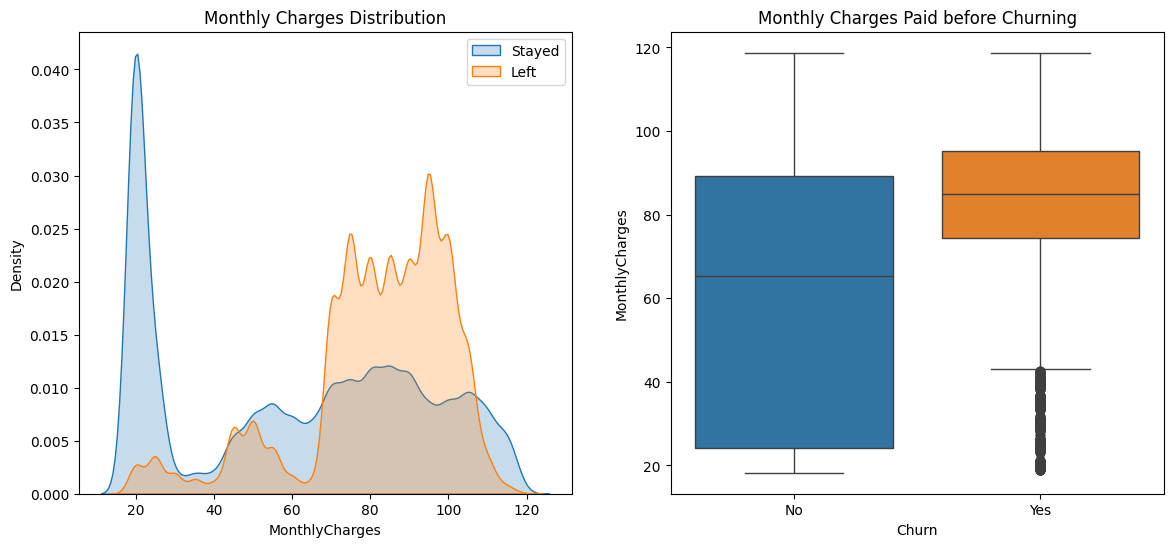

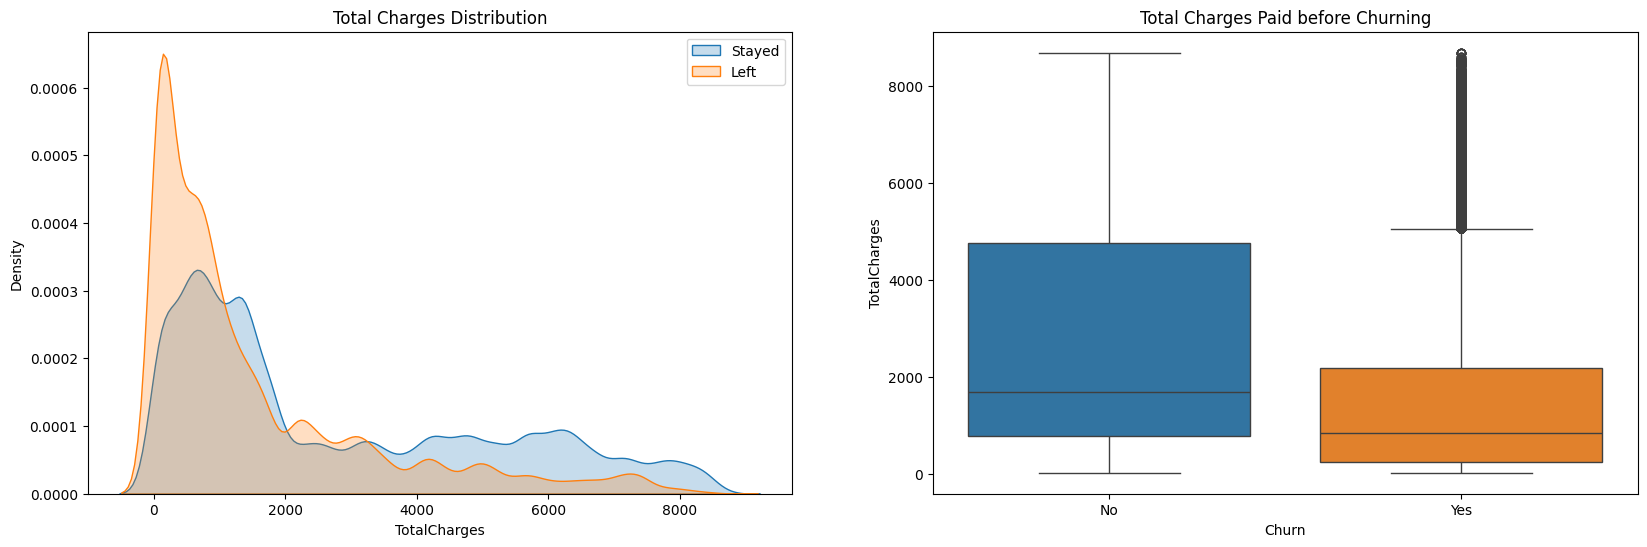

In [ ]:
# Monthly Charges Analysis
fig, ax = subplots(1, 2, figsize=(14, 6))
sns.kdeplot(data=train[train['Churn'] == 'No'], x='MonthlyCharges', label='Stayed', fill=True, ax=ax[0])
sns.kdeplot(data=train[train['Churn'] == 'Yes'], x='MonthlyCharges', label='Left', fill=True, ax=ax[0])
ax[0].set_title("Monthly Charges Distribution")
ax[0].legend()

sns.boxplot(data=train, x='Churn', y='MonthlyCharges', ax=ax[1], hue='Churn')
ax[1].set_title("Monthly Charges Paid before Churning")
plt.show()

# Total Charges Analysis
fig, ax = subplots(nrows=1, ncols=2, figsize=(20, 6))
sns.kdeplot(data=train[train['Churn'] == 'No'], x='TotalCharges', label='Stayed', fill=True, ax=ax[0])
sns.kdeplot(data=train[train['Churn'] == 'Yes'], x='TotalCharges', label='Left', fill=True, ax=ax[0])
ax[0].set_title("Total Charges Distribution")
ax[0].legend()

sns.boxplot(data=train, x='Churn', y='TotalCharges', ax=ax[1], hue='Churn')
ax[1].set_title("Total Charges Paid before Churning")
plt.show()


### Churn probability vs Tenure of high paying customers.

In [ ]:
train['Churn_Numeric'] = train['Churn'].map({'Yes':1, 'No':0})


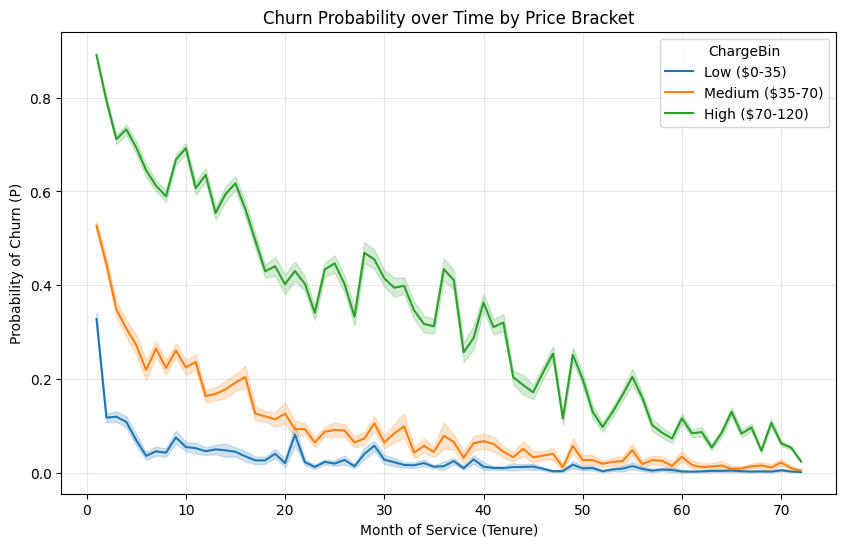

In [ ]:
bins = [0, 35, 70, 120]
labels = ['Low ($0-35)', 'Medium ($35-70)', 'High ($70-120)']
train['ChargeBin'] = pd.cut(train['MonthlyCharges'], bins=bins, labels=labels)
plt.figure(figsize=(10,6))
sns.lineplot(data=train, x='tenure', y='Churn_Numeric', hue='ChargeBin')
plt.title("Churn Probability over Time by Price Bracket")
plt.ylabel("Probability of Churn (P)")
plt.xlabel("Month of Service (Tenure)")
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Churn Rate by Price Bracket
print(train.groupby('ChargeBin', observed=True)['Churn'].value_counts())
print('*'*30)

# Proportion of churners in each price bracket
print(train['ChargeBin'].value_counts(normalize=True))


ChargeBin        Churn
Low ($0-35)      No       147425
                 Yes        5319
Medium ($35-70)  No       100734
                 Yes       19290
High ($70-120)   No       212218
                 Yes      109208
Name: count, dtype: int64
******************************
ChargeBin
High ($70-120)     0.540945
Low ($0-35)        0.257061
Medium ($35-70)    0.201995
Name: proportion, dtype: float64


In [ ]:
train.groupby(['ChargeBin', 'InternetService'], observed=True)['Churn'].value_counts(normalize=True)


ChargeBin        InternetService  Churn
Low ($0-35)      DSL              No       0.728288
                                  Yes      0.271712
                 Fiber optic      Yes      0.583333
                                  No       0.416667
                 No               No       0.985688
                                  Yes      0.014312
Medium ($35-70)  DSL              No       0.871235
                                  Yes      0.128765
                 Fiber optic      No       0.513745
                                  Yes      0.486255
                 No               No       1.000000
High ($70-120)   DSL              No       0.977359
                                  Yes      0.022641
                 Fiber optic      No       0.587619
                                  Yes      0.412381
Name: proportion, dtype: float64

In [ ]:
train.groupby(['ChargeBin', 'Partner'], observed=True)['Churn'].value_counts(normalize=True)


ChargeBin        Partner  Churn
Low ($0-35)      No       No       0.941697
                          Yes      0.058303
                 Yes      No       0.983173
                          Yes      0.016827
Medium ($35-70)  No       No       0.778940
                          Yes      0.221060
                 Yes      No       0.919301
                          Yes      0.080699
High ($70-120)   No       No       0.510407
                          Yes      0.489593
                 Yes      No       0.791247
                          Yes      0.208753
Name: proportion, dtype: float64

In [ ]:
train.groupby(['ChargeBin', 'Dependents'], observed=True)['Churn'].value_counts(normalize=True)


ChargeBin        Dependents  Churn
Low ($0-35)      No          No       0.947408
                             Yes      0.052592
                 Yes         No       0.984627
                             Yes      0.015373
Medium ($35-70)  No          No       0.801048
                             Yes      0.198952
                 Yes         No       0.932527
                             Yes      0.067473
High ($70-120)   No          No       0.600700
                             Yes      0.399300
                 Yes         No       0.866471
                             Yes      0.133529
Name: proportion, dtype: float64

In [ ]:
train.groupby(['ChargeBin', 'SeniorCitizen'], observed=True)['Churn'].value_counts(normalize=True)


ChargeBin        SeniorCitizen  Churn
Low ($0-35)      0              No       0.968465
                                Yes      0.031535
                 1              No       0.767507
                                Yes      0.232493
Medium ($35-70)  0              No       0.852718
                                Yes      0.147282
                 1              No       0.619041
                                Yes      0.380959
High ($70-120)   0              No       0.701563
                                Yes      0.298437
                 1              Yes      0.525882
                                No       0.474118
Name: proportion, dtype: float64

### Insights

#### 1. Customer Distribution by Price Bracket

| Price Bracket | Share of Customers |
|---|---:|
| High ($70-120) | 54.09% |
| Low ($0-35) | 25.71% |
| Medium ($35-70) | 20.20% |

The customer base is concentrated in the **high monthly charge** segment, which makes this bracket especially important for churn analysis and revenue protection.

#### 2. Fiber Optic is the strongest churn-risk signal inside the higher-paying population

- In the **high-price bracket**, Fiber Optic customers churn at **41.24%**, while DSL customers churn at only **2.26%**.
- In the **medium-price bracket**, Fiber Optic customers churn at **48.63%**, making them nearly a 50-50 churn/non-churn segment.
- Across all price brackets, Fiber Optic customers are much less stable than DSL customers.

This suggests that high spend alone is not the main issue. The real churn concentration sits inside the **Fiber Optic** segment.

#### 3. High-paying customers without family anchors are much more likely to churn

- In the **high-price bracket**, customers with **no partner** churn at **48.96%**, compared with **20.88%** for customers with a partner.
- In the same bracket, customers with **no dependents** churn at **39.93%**, compared with **13.35%** for customers with dependents.

This indicates that socially less anchored high-paying customers are more vulnerable to attrition.

#### 4. Senior citizens amplify churn in the high-price segment

- In the **high-price bracket**, non-senior customers churn at **29.84%**.
- High-paying **senior citizens** churn at **52.59%**, which is the highest-risk subgroup in the notebook.

This means high spend becomes especially risky when combined with senior status.


#### Final Takeaway

High-paying customers are not uniformly risky. The real danger segment is the **high-charge Fiber Optic customer**, especially when that customer is a **senior citizen**, has **no partner**, or has **no dependents**.

A practical business recommendation is to prioritize retention efforts on high-charge Fiber Optic customers first, especially seniors and customers without family-linked stability.
